# Pixels to Predictions v21 — Curriculum Learning

**Model:** `HuggingFaceTB/SmolVLM-500M-Instruct`  
**Base:** v19 config (LoRA r=18, alpha=36, DoRA, 4.79M params, 40K dataset)

**What changed from v19:**
1. **Curriculum learning** — progressive difficulty:
   - Phase 1 (epochs 1-2): 2-choice + 3-choice only (easy, ~91-94% acc)
   - Phase 2 (epochs 3-4): Add 4-choice (medium, ~89-93% acc)
   - Phase 3 (epochs 5-6): Full dataset incl. 5-choice (hard, ~57-64% acc)

**Motivation:**
- 5-choice questions are ALL genetics Punnett squares (grade 8 biology) — fundamentally harder
- Standard training equally weights all difficulty levels from epoch 1
- Curriculum learning lets the model first learn "how to do MCQ" on easy questions,
  then progressively tackle harder visual reasoning
- Paper: "Task Progressive Curriculum Learning for Robust VQA" (arXiv:2411.17292) shows +5-7% gains

**Everything else identical to v19:** same LoRA, same augmentation targets, same hyperparams

**Scoreboard:** v16=0.91549, v16-TTA=0.92354, v19=0.91951, v19-ensemble=0.92555

## 0. Install Dependencies

In [ ]:
!pip install -q "transformers==4.47.0"

!pip uninstall -y torchao 2>/dev/null

!pip install -q accelerate peft bitsandbytes datasets pillow tqdm pandas

import transformers, peft
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")
print("All good. If first run, do Runtime -> Restart session, then run all cells.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 70.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 120.4 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 39.4 MB/s eta 0:00:00
transformers: 4.47.0
peft: 0.19.1
All good. If first run, do Runtime -> Restart session, then run all cells.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Configuration

In [ ]:
import transformers
print(f"transformers: {transformers.__version__}")
assert transformers.__version__ >= "4.45.0", f"Too old: {transformers.__version__}"

import os, json, re, random, copy, math
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm
from itertools import permutations

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

DATA_DIR = "/content/drive/MyDrive/pixels-to-predictions"
IMG_BASE = os.path.join(DATA_DIR, "images")

OUTPUT_DIR = "/content/smolvlm-lora-v21"
CKPT_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v21"
os.makedirs(CKPT_DIR, exist_ok=True)

LORA_RANK = 18
LORA_ALPHA = 36
LORA_DROPOUT = 0.05

IMAGE_LONGEST_EDGE = 512

LEARNING_RATE = 2e-4
BATCH_SIZE = 8
GRAD_ACCUM_STEPS = 2
NUM_EPOCHS = 6
WARMUP_RATIO = 0.1
MAX_SEQ_LEN = 1024
LABEL_SMOOTHING = 0.1
SEED = 42

TARGET_PER_TYPE = 10000

CURRICULUM = {
    1: [2, 3],
    2: [2, 3],
    3: [2, 3, 4],
    4: [2, 3, 4],
    5: [2, 3, 4, 5],
    6: [2, 3, 4, 5],
}

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"\nCurriculum Schedule:")
for ep, choices in CURRICULUM.items():
    n_samples = len(choices) * TARGET_PER_TYPE
    print(f"  Epoch {ep}: {choices}-choice → {n_samples} samples")

transformers: 4.47.0
Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB

Curriculum Schedule:
  Epoch 1: [2, 3]-choice → 20000 samples
  Epoch 2: [2, 3]-choice → 20000 samples
  Epoch 3: [2, 3, 4]-choice → 30000 samples
  Epoch 4: [2, 3, 4]-choice → 30000 samples
  Epoch 5: [2, 3, 4, 5]-choice → 40000 samples
  Epoch 6: [2, 3, 4, 5]-choice → 40000 samples


## 2. Load Data & Balanced Factorial Augmentation

In [ ]:
train_df_orig = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Original Train: {len(train_df_orig)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nOriginal distribution by num_choices:")
print(train_df_orig['num_choices'].value_counts().sort_index())

def apply_permutation(row, perm):
    """Apply a specific permutation to choices and remap answer."""
    choices = json.loads(row['choices'])
    answer = int(row['answer'])
    new_choices = [choices[perm[i]] for i in range(len(perm))]
    new_answer = list(perm).index(answer)
    new_row = row.copy()
    new_row['choices'] = json.dumps(new_choices)
    new_row['answer'] = new_answer
    return new_row

rng = random.Random(SEED)
shuffled_rows = []

for nc in [2, 3, 4, 5]:
    subset = train_df_orig[train_df_orig['num_choices'] == nc]
    n_base = len(subset)
    n_perms = math.factorial(nc)
    all_perms = list(permutations(range(nc)))

    ppq = TARGET_PER_TYPE / n_base
    k_floor = int(ppq)
    k_ceil = k_floor + 1
    n_ceil = TARGET_PER_TYPE - n_base * k_floor
    n_floor = n_base - n_ceil

    count = 0
    for q_idx, (_, row) in enumerate(subset.iterrows()):
        k = k_ceil if q_idx < n_ceil else k_floor

        if k <= n_perms:
            selected_perms = rng.sample(all_perms, k)
        else:
            full_rounds = k // n_perms
            remainder = k % n_perms
            selected_perms = all_perms * full_rounds
            if remainder > 0:
                selected_perms += rng.sample(all_perms, remainder)

        for perm in selected_perms:
            shuffled_rows.append(apply_permutation(row, perm))
            count += 1

    print(f"  {nc}-choice: {n_base} base → {count} augmented (target: {TARGET_PER_TYPE})")

train_df_full = pd.DataFrame(shuffled_rows).reset_index(drop=True)

print(f"\nTotal augmented train: {len(train_df_full)}")
print(f"\nAugmented distribution by num_choices:")
print(train_df_full['num_choices'].value_counts().sort_index())

print(f"\nAnswer distribution (should be ~uniform within each choice type):")
for nc in [2, 3, 4, 5]:
    sub = train_df_full[train_df_full['num_choices'] == nc]
    dist = sub['answer'].value_counts().sort_index()
    print(f"  {nc}-choice: {dict(dist)}")

shuf_row = train_df_full.iloc[0]
orig_row = train_df_orig[train_df_orig['id'] == shuf_row['id']].iloc[0]
orig_choices = json.loads(orig_row['choices'])
shuf_choices = json.loads(shuf_row['choices'])
assert orig_choices[int(orig_row['answer'])] == shuf_choices[int(shuf_row['answer'])], "SHUFFLE BUG!"
print(f"\nSpot check passed!")

for i in random.sample(range(len(train_df_full)), 100):
    row = train_df_full.iloc[i]
    orig = train_df_orig[train_df_orig['id'] == row['id']].iloc[0]
    oc = json.loads(orig['choices'])
    sc = json.loads(row['choices'])
    assert oc[int(orig['answer'])] == sc[int(row['answer'])], f"SHUFFLE BUG at {row['id']}!"
print(f"100 random spot checks passed!")

sample_path = os.path.join(IMG_BASE, train_df_full['image_path'].iloc[0])
assert os.path.exists(sample_path), f"Image not found: {sample_path}"
print(f"\nImages accessible at {IMG_BASE}")

Original Train: 3109 | Val: 1048 | Test: 1008

Original distribution by num_choices:
num_choices
2     664
3    1552
4     783
5     110
Name: count, dtype: int64
  2-choice: 664 base → 10000 augmented (target: 10000)
  3-choice: 1552 base → 10000 augmented (target: 10000)
  4-choice: 783 base → 10000 augmented (target: 10000)
  5-choice: 110 base → 10000 augmented (target: 10000)

Total augmented train: 40000

Augmented distribution by num_choices:
num_choices
2    10000
3    10000
4    10000
5    10000
Name: count, dtype: int64

Answer distribution (should be ~uniform within each choice type):
  2-choice: {0: np.int64(4995), 1: np.int64(5005)}
  3-choice: {0: np.int64(3349), 1: np.int64(3306), 2: np.int64(3345)}
  4-choice: {0: np.int64(2469), 1: np.int64(2546), 2: np.int64(2503), 3: np.int64(2482)}
  5-choice: {0: np.int64(2014), 1: np.int64(2041), 2: np.int64(1996), 3: np.int64(1981), 4: np.int64(1968)}

Spot check passed!
100 random spot checks passed!

Images accessible at /conte

## 2.1 Curriculum Subsets

Pre-split the full augmented dataset by num_choices so we can dynamically compose each epoch's training set.

In [ ]:
train_by_nc = {}
for nc in [2, 3, 4, 5]:
    train_by_nc[nc] = train_df_full[train_df_full['num_choices'] == nc].reset_index(drop=True)
    print(f"  {nc}-choice subset: {len(train_by_nc[nc])} samples")

print(f"\nCurriculum plan:")
for ep, choice_types in CURRICULUM.items():
    n = sum(len(train_by_nc[nc]) for nc in choice_types)
    print(f"  Epoch {ep}: types {choice_types} → {n} samples, {n // BATCH_SIZE} batches")

  2-choice subset: 10000 samples
  3-choice subset: 10000 samples
  4-choice subset: 10000 samples
  5-choice subset: 10000 samples

Curriculum plan:
  Epoch 1: types [2, 3] → 20000 samples, 2500 batches
  Epoch 2: types [2, 3] → 20000 samples, 2500 batches
  Epoch 3: types [2, 3, 4] → 30000 samples, 3750 batches
  Epoch 4: types [2, 3, 4] → 30000 samples, 3750 batches
  Epoch 5: types [2, 3, 4, 5] → 40000 samples, 5000 batches
  Epoch 6: types [2, 3, 4, 5] → 40000 samples, 5000 batches


## 3. Load Model & Processor

In [ ]:
MODEL_CACHE_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/base_model_cache"
PROCESSOR_CACHE_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/processor_cache"

if os.path.exists(os.path.join(MODEL_CACHE_DIR, "config.json")):
    print("Loading base model from Drive cache (skipping HuggingFace download)...")
    model = AutoModelForVision2Seq.from_pretrained(
        MODEL_CACHE_DIR,
        torch_dtype=torch.float16,
        device_map="auto",
    )
    processor = AutoProcessor.from_pretrained(PROCESSOR_CACHE_DIR)
else:
    print("Downloading base model from HuggingFace (first run)...")
    processor = AutoProcessor.from_pretrained(MODEL_ID)
    model = AutoModelForVision2Seq.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto",
    )

processor.image_processor.size = {"longest_edge": IMAGE_LONGEST_EDGE}

print(f"Image processor size: {processor.image_processor.size}")
print(f"Model type: {type(model).__name__}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Some kwargs in processor config are unused and will not have any effect: image_seq_len. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Image processor size: {'longest_edge': 512}
Model type: Idefics3ForConditionalGeneration


## 4. Apply LoRA + DoRA

In [ ]:
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    task_type=TaskType.CAUSAL_LM,
    bias="none",
    use_dora=True,
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"Total parameters:     {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Trainable %:          {100 * trainable_params / total_params:.2f}%")

assert trainable_params <= 5_000_000, f"OVER BUDGET: {trainable_params:,} > 5,000,000"
print(f"\nUnder 5M cap ({trainable_params:,} <= 5,000,000)")
print(f"DoRA enabled: {lora_config.use_dora}")
print(f"Targets: {lora_config.target_modules}")

Trainable parameters: 4,791,296 (4.79M)
Total parameters:     512,273,600 (512.3M)
Trainable %:          0.94%

Under 5M cap (4,791,296 <= 5,000,000)
DoRA enabled: True
Targets: {'o_proj', 'v_proj', 'q_proj', 'k_proj'}


## 5. Prompt & Dataset

In [ ]:
def build_prompt(row, include_answer=False):
    """Identical to v16/v19."""
    choices = json.loads(row['choices'])
    choices_text = "\n".join(f"({i}) {c}" for i, c in enumerate(choices))

    parts = []
    if pd.notna(row.get('hint', None)) and str(row['hint']).strip():
        parts.append(f"Context: {row['hint'].strip()}")
    if pd.notna(row.get('lecture', None)) and str(row['lecture']).strip():
        parts.append(f"Background: {row['lecture'].strip()}")

    parts.append(f"Question: {row['question'].strip()}")
    parts.append(f"Choices:\n{choices_text}")
    parts.append("Answer with ONLY the number of the correct choice.")

    prompt_text = "\n\n".join(parts)

    if include_answer:
        answer_text = str(int(row['answer']))
        return prompt_text, answer_text
    return prompt_text

class ScienceVQADataset(Dataset):
    def __init__(self, df, img_base, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_base = img_base
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_base, row['image_path'])
        image = Image.open(img_path).convert("RGB")

        if self.is_test:
            prompt_text = build_prompt(row, include_answer=False)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": None, "is_test": True}
        else:
            prompt_text, answer_text = build_prompt(row, include_answer=True)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": answer_text, "is_test": False}

val_dataset = ScienceVQADataset(val_df, IMG_BASE, is_test=False)
test_dataset = ScienceVQADataset(test_df, IMG_BASE, is_test=True)

print(f"Val: {len(val_dataset)} | Test: {len(test_dataset)}")

sample = train_df_full.iloc[0]
prompt, answer = build_prompt(sample, include_answer=True)
print(f"\nSample prompt (first 300 chars):\n{prompt[:300]}")
print(f"\n>>> TARGET ANSWER: {answer}")

Val: 1048 | Test: 1008

Sample prompt (first 300 chars):
Context: The passage below describes an experiment. Read the passage and then follow the instructions below.

Kathleen applied a thin layer of wax to the underside of her snowboard and rode the board straight down a hill. Then, she removed the wax and rode the snowboard straight down the hill again.

>>> TARGET ANSWER: 0


## 6. DataLoader (with curriculum-aware epoch datasets)

In [ ]:
from functools import partial

def collate_fn(batch, processor, max_length=MAX_SEQ_LEN):
    ids = [item["id"] for item in batch]
    images = [item["image"] for item in batch]
    is_test = batch[0]["is_test"]

    texts = []
    answer_texts = []
    for item in batch:
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": item["prompt_text"]},
        ]}]
        if not is_test:
            messages.append({"role": "assistant", "content": [
                {"type": "text", "text": item["answer_text"]},
            ]})
            answer_texts.append(item["answer_text"])
        text = processor.apply_chat_template(messages, add_generation_prompt=is_test)
        texts.append(text)

    inputs = processor(
        text=texts, images=images, return_tensors="pt",
        padding=True, truncation=True, max_length=max_length,
    )

    if not is_test:
        labels = inputs["input_ids"].clone()
        eos_token_id = processor.tokenizer.eos_token_id

        for i in range(len(batch)):
            labels[i, :] = -100

            eos_positions = (inputs["input_ids"][i] == eos_token_id).nonzero(as_tuple=True)[0]
            if len(eos_positions) < 1:
                continue
            last_eos_pos = eos_positions[-1].item()

            ans_tokens = processor.tokenizer.encode(answer_texts[i], add_special_tokens=False)
            n_ans = len(ans_tokens)
            start = last_eos_pos - n_ans

            labels[i, start:last_eos_pos] = inputs["input_ids"][i, start:last_eos_pos]
            labels[i, last_eos_pos] = eos_token_id

        inputs["labels"] = labels

    inputs["id"] = ids
    return dict(inputs)

collate = partial(collate_fn, processor=processor)

def make_curriculum_loader(epoch_num):
    """Create a DataLoader for the given epoch based on curriculum schedule."""
    choice_types = CURRICULUM[epoch_num]
    epoch_df = pd.concat([train_by_nc[nc] for nc in choice_types], ignore_index=True)
    epoch_dataset = ScienceVQADataset(epoch_df, IMG_BASE, is_test=False)
    loader = DataLoader(
        epoch_dataset, batch_size=BATCH_SIZE, shuffle=True,
        collate_fn=collate, num_workers=2, pin_memory=True,
    )
    return loader, len(epoch_df)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=2, pin_memory=True,
)

print(f"Val batches: {len(val_loader)}")
print(f"\nCurriculum DataLoader sizes:")
for ep in range(1, NUM_EPOCHS + 1):
    choice_types = CURRICULUM[ep]
    n = sum(len(train_by_nc[nc]) for nc in choice_types)
    print(f"  Epoch {ep}: {choice_types} → {n} samples, {n // BATCH_SIZE} batches")

sample_batch = next(iter(val_loader))
print(f"\ninput_ids: {sample_batch['input_ids'].shape}")
print(f"pixel_values: {sample_batch['pixel_values'].shape}")
for i in range(min(2, len(sample_batch['id']))):
    label_mask = sample_batch['labels'][i] != -100
    label_positions = label_mask.nonzero(as_tuple=True)[0]
    labeled_tokens = sample_batch['labels'][i][label_positions]
    decoded = processor.tokenizer.decode(labeled_tokens)
    print(f"  Sample {i}: '{decoded.strip()}'")

Val batches: 131

Curriculum DataLoader sizes:
  Epoch 1: [2, 3] → 20000 samples, 2500 batches
  Epoch 2: [2, 3] → 20000 samples, 2500 batches
  Epoch 3: [2, 3, 4] → 30000 samples, 3750 batches
  Epoch 4: [2, 3, 4] → 30000 samples, 3750 batches
  Epoch 5: [2, 3, 4, 5] → 40000 samples, 5000 batches
  Epoch 6: [2, 3, 4, 5] → 40000 samples, 5000 batches

input_ids: torch.Size([8, 739])
pixel_values: torch.Size([8, 1, 3, 512, 512])
  Sample 0: '0<end_of_utterance>'
  Sample 1: '1<end_of_utterance>'


## 7. Training Loop — Curriculum Learning

Key difference from v19: each epoch gets a **different DataLoader** based on the curriculum schedule.
The LR scheduler is computed over total steps across all epochs.

In [ ]:
total_batches = 0
for ep in range(1, NUM_EPOCHS + 1):
    choice_types = CURRICULUM[ep]
    n = sum(len(train_by_nc[nc]) for nc in choice_types)
    total_batches += n // BATCH_SIZE

total_steps = total_batches // GRAD_ACCUM_STEPS
warmup_steps = int(total_steps * WARMUP_RATIO)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01,
)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total batches across all epochs: {total_batches}")
print(f"Total optimizer steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"\nPer-epoch breakdown:")
for ep in range(1, NUM_EPOCHS + 1):
    choice_types = CURRICULUM[ep]
    n = sum(len(train_by_nc[nc]) for nc in choice_types)
    batches = n // BATCH_SIZE
    steps = batches // GRAD_ACCUM_STEPS
    print(f"  Epoch {ep}: {n} samples, {batches} batches, {steps} optimizer steps")

Total batches across all epochs: 22500
Total optimizer steps: 11250
Warmup steps: 1125
Label smoothing: 0.1

Per-epoch breakdown:
  Epoch 1: 20000 samples, 2500 batches, 1250 optimizer steps
  Epoch 2: 20000 samples, 2500 batches, 1250 optimizer steps
  Epoch 3: 30000 samples, 3750 batches, 1875 optimizer steps
  Epoch 4: 30000 samples, 3750 batches, 1875 optimizer steps
  Epoch 5: 40000 samples, 5000 batches, 2500 optimizer steps
  Epoch 6: 40000 samples, 5000 batches, 2500 optimizer steps


In [ ]:
loss_fn = nn.CrossEntropyLoss(ignore_index=-100, label_smoothing=LABEL_SMOOTHING)

def compute_loss(logits, labels):
    """Shift logits/labels for next-token prediction, apply label-smoothed CE."""
    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = labels[:, 1:].contiguous()
    shift_logits = shift_logits.view(-1, shift_logits.size(-1))
    shift_labels = shift_labels.view(-1)
    return loss_fn(shift_logits, shift_labels)

print(f"Loss function: CrossEntropyLoss with label_smoothing={LABEL_SMOOTHING}")

Loss function: CrossEntropyLoss with label_smoothing=0.1


In [ ]:
@torch.no_grad()
def evaluate(model, dataloader, processor):
    """Teacher-forced val loss + accuracy."""
    model.eval()
    correct, total, total_loss, num_batches = 0, 0, 0, 0

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch)
            loss = compute_loss(outputs.logits, labels)
        total_loss += loss.item()
        num_batches += 1

        logits = outputs.logits
        for i in range(len(ids)):
            label_positions = (labels[i] != -100).nonzero(as_tuple=True)[0]
            if len(label_positions) == 0:
                continue
            ans_pos = label_positions[0].item()
            pred_token = logits[i, ans_pos - 1, :].argmax().item()
            true_token = labels[i, ans_pos].item()
            if pred_token == true_token:
                correct += 1
            total += 1

    model.train()
    return total_loss / max(num_batches, 1), correct / max(total, 1)

has_checkpoint = os.path.exists(os.path.join(CKPT_DIR, "training_state.pt"))
if not has_checkpoint:
    print("Pre-training evaluation...")
    val_loss, val_acc = evaluate(model, val_loader, processor)
    print(f"Pre-training — Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
else:
    print("Checkpoint found — skipping pre-training eval")

Checkpoint found — skipping pre-training eval


In [ ]:
def save_epoch_checkpoint(model, processor, epoch, ckpt_dir):
    """Save adapter for this specific epoch (never overwritten)."""
    epoch_dir = os.path.join(ckpt_dir, f"epoch_{epoch+1}")
    os.makedirs(epoch_dir, exist_ok=True)
    model.save_pretrained(epoch_dir)
    processor.save_pretrained(epoch_dir)
    print(f"  Epoch {epoch+1} adapter saved to {epoch_dir}")

def save_training_state(model, optimizer, scheduler, scaler, epoch, step,
                        best_val_acc, train_losses, val_losses, val_accs, path):
    """Save latest training state for resume."""
    model.save_pretrained(os.path.join(path, "lora_adapter"))
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch, "step": step,
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
    }, os.path.join(path, "training_state.pt"))
    print(f"  Training state saved to {path}")

def load_training_state(model, optimizer, scheduler, scaler, path):
    state_path = os.path.join(path, "training_state.pt")
    adapter_path = os.path.join(path, "lora_adapter")
    if not os.path.exists(state_path):
        return 0, 0, 0.0, [], [], []
    state = torch.load(state_path, map_location=device, weights_only=False)

    if os.path.exists(adapter_path):
        from peft import set_peft_model_state_dict
        from safetensors.torch import load_file
        adapter_weights_path = os.path.join(adapter_path, "adapter_model.safetensors")
        if os.path.exists(adapter_weights_path):
            adapter_state = load_file(adapter_weights_path)
            set_peft_model_state_dict(model, adapter_state)
            print(f"  Loaded adapter weights from {adapter_path}")

    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    scaler.load_state_dict(state["scaler"])

    print(f"  Resumed from epoch {state['epoch']}, best_acc={state['best_val_acc']:.4f}")
    return (state["epoch"], state["step"], state["best_val_acc"],
            state["train_losses"], state["val_losses"], state["val_accs"])

In [ ]:
scaler = torch.amp.GradScaler("cuda")

start_epoch, start_step, best_val_acc, train_losses, val_losses, val_accs = \
    load_training_state(model, optimizer, scheduler, scaler, CKPT_DIR)

if start_epoch > 0:
    print(f"Resuming from epoch {start_epoch + 1}")
else:
    best_val_acc = 0.0
    train_losses, val_losses, val_accs = [], [], []
    print("Starting curriculum training from scratch")

model.train()

for epoch in range(start_epoch, NUM_EPOCHS):
    choice_types = CURRICULUM[epoch + 1]
    train_loader, n_samples = make_curriculum_loader(epoch + 1)

    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Curriculum: {choice_types}-choice ({n_samples} samples)")
    print(f"{'='*60}")

    epoch_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for step, batch in enumerate(pbar):
        if epoch == start_epoch and step < start_step:
            continue

        ids = batch.pop("id")
        labels = batch.pop("labels")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch)
            loss = compute_loss(outputs.logits, labels)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % 500 == 0:
            pbar.set_postfix({"loss": f"{epoch_loss / (step+1):.4f}",
                              "lr": f"{scheduler.get_last_lr()[0]:.2e}"})

    start_step = 0

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loss, val_acc = evaluate(model, val_loader, processor)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS} — Curriculum: {choice_types}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val Acc:    {val_acc:.4f}")
    print(f"  LR:         {scheduler.get_last_lr()[0]:.2e}")

    save_epoch_checkpoint(model, processor, epoch, CKPT_DIR)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        print(f"  ★ New best val acc! Saved to {OUTPUT_DIR}")

    save_training_state(model, optimizer, scheduler, scaler, epoch + 1, 0,
                        best_val_acc, train_losses, val_losses, val_accs, CKPT_DIR)

print(f"\n{'='*60}")
print(f"CURRICULUM TRAINING COMPLETE")
print(f"{'='*60}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")
print(f"\nPer-epoch results:")
for i in range(len(train_losses)):
    curriculum = CURRICULUM[i + 1]
    marker = " ★ best" if val_accs[i] == best_val_acc else ""
    print(f"  E{i+1} ({curriculum}): train={train_losses[i]:.4f} val_loss={val_losses[i]:.4f} val_acc={val_accs[i]:.4f}{marker}")

  Loaded adapter weights from /content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/lora_adapter
  Resumed from epoch 5, best_acc=0.8998
Resuming from epoch 6

Epoch 6/6 — Curriculum: [2, 3, 4, 5]-choice (40000 samples)


Epoch 6/6:   0%|          | 0/5000 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/131 [00:00<?, ?it/s]


Epoch 6/6 — Curriculum: [2, 3, 4, 5]
  Train Loss: 1.4235
  Val Loss:   1.7317
  Val Acc:    0.8998
  LR:         0.00e+00
  Epoch 6 adapter saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_6
  Training state saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v21

CURRICULUM TRAINING COMPLETE
Best Val Accuracy: 0.8998

Per-epoch results:
  E1 ([2, 3]): train=1.7334 val_loss=1.7007 val_acc=0.8177
  E2 ([2, 3]): train=1.4554 val_loss=1.7908 val_acc=0.8263
  E3 ([2, 3, 4]): train=1.4581 val_loss=1.6702 val_acc=0.8655
  E4 ([2, 3, 4]): train=1.4270 val_loss=1.7308 val_acc=0.8798
  E5 ([2, 3, 4, 5]): train=1.4672 val_loss=1.7285 val_acc=0.8998 ★ best
  E6 ([2, 3, 4, 5]): train=1.4235 val_loss=1.7317 val_acc=0.8998 ★ best


## 8. Training Curves

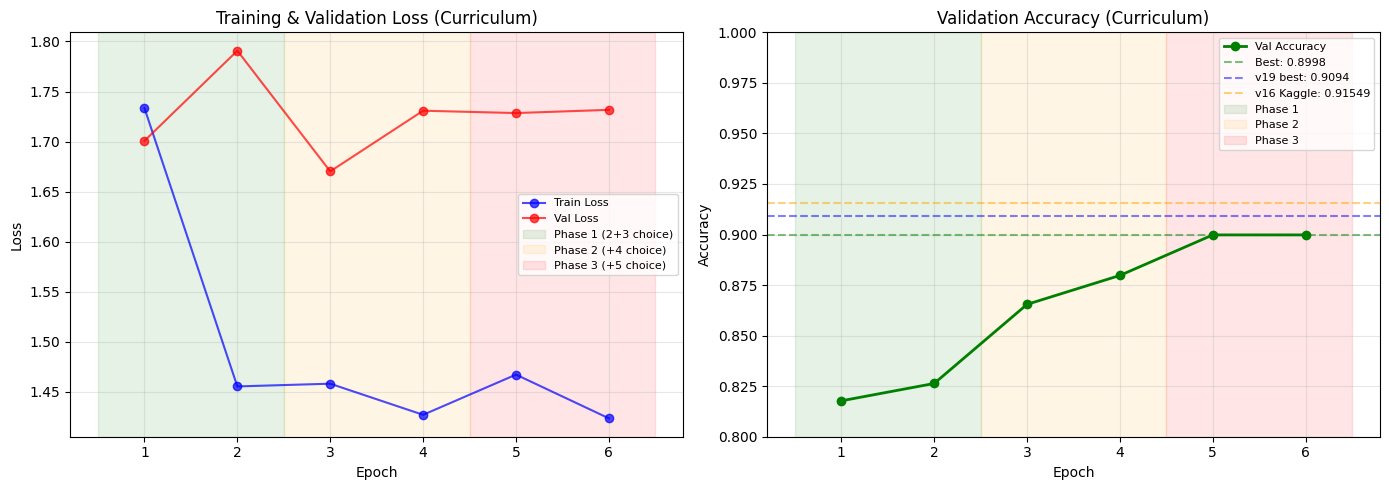

Saved training_curves_v21.png


In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_x = range(1, len(train_losses) + 1)

phase_colors = {1: '#4CAF50', 2: '#4CAF50', 3: '#FF9800', 4: '#FF9800', 5: '#F44336', 6: '#F44336'}
colors = [phase_colors[e] for e in epochs_x]

ax1.plot(epochs_x, train_losses, 'b-o', label='Train Loss', alpha=0.7)
ax1.plot(epochs_x, val_losses, 'r-o', label='Val Loss', alpha=0.7)
ax1.axvspan(0.5, 2.5, alpha=0.1, color='green', label='Phase 1 (2+3 choice)')
ax1.axvspan(2.5, 4.5, alpha=0.1, color='orange', label='Phase 2 (+4 choice)')
ax1.axvspan(4.5, 6.5, alpha=0.1, color='red', label='Phase 3 (+5 choice)')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss (Curriculum)'); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

ax2.plot(epochs_x, val_accs, 'g-o', label='Val Accuracy', linewidth=2)
ax2.axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.4f}')
ax2.axhline(y=0.9094, color='blue', linestyle='--', alpha=0.5, label='v19 best: 0.9094')
ax2.axhline(y=0.91549, color='orange', linestyle='--', alpha=0.5, label='v16 Kaggle: 0.91549')
ax2.axvspan(0.5, 2.5, alpha=0.1, color='green', label='Phase 1')
ax2.axvspan(2.5, 4.5, alpha=0.1, color='orange', label='Phase 2')
ax2.axvspan(4.5, 6.5, alpha=0.1, color='red', label='Phase 3')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy (Curriculum)'); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.8, 1.0)

plt.tight_layout()
plt.savefig('training_curves_v21.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved training_curves_v21.png")

## 9. Generate Predictions — Best Val Acc Model

In [18]:
best_adapter_path = OUTPUT_DIR
if not os.path.exists(os.path.join(OUTPUT_DIR, "adapter_config.json")):
    best_adapter_path = os.path.join(CKPT_DIR, "lora_adapter")
    print(f"Local output missing, loading from Drive: {best_adapter_path}")

del model
torch.cuda.empty_cache()

base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID if not os.path.exists(os.path.join(MODEL_CACHE_DIR, "config.json")) else MODEL_CACHE_DIR,
    torch_dtype=torch.float16, device_map="auto")
model = PeftModel.from_pretrained(base_model, best_adapter_path)
model.eval()
print(f"Loaded best val acc model from {best_adapter_path}")

Local output missing, loading from Drive: /content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/lora_adapter
Loaded best val acc model from /content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/lora_adapter


In [19]:
DIGIT_TOKEN_IDS = [processor.tokenizer.encode(str(d), add_special_tokens=False)[0] for d in range(10)]
print(f"Digit token IDs: { {d: DIGIT_TOKEN_IDS[d] for d in range(5)} }")

@torch.no_grad()
def predict_digit_logits(model, processor, df, img_base, batch_size=4):
    """Score digit-token logits at the last position."""
    model.eval()
    all_ids, all_preds = [], []

    for start in tqdm(range(0, len(df), batch_size), desc="Predicting"):
        batch_df = df.iloc[start:start + batch_size]
        images, texts, batch_ids, nc_list = [], [], [], []

        for _, row in batch_df.iterrows():
            images.append(Image.open(os.path.join(img_base, row['image_path'])).convert("RGB"))
            prompt = build_prompt(row, include_answer=False)
            messages = [{"role": "user", "content": [
                {"type": "image"}, {"type": "text", "text": prompt}]}]
            texts.append(processor.apply_chat_template(messages, add_generation_prompt=True))
            batch_ids.append(row['id'])
            nc_list.append(row['num_choices'])

        inputs = processor(text=texts, images=images, return_tensors="pt",
                           padding=True, truncation=True, max_length=MAX_SEQ_LEN).to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**inputs)
        logits = outputs.logits

        for i in range(len(batch_df)):
            last_pos = inputs["attention_mask"][i].sum().item() - 1
            next_logits = logits[i, last_pos, :]
            nc = nc_list[i]
            scores = torch.stack([next_logits[DIGIT_TOKEN_IDS[d]] for d in range(nc)])
            all_preds.append(scores.argmax().item())
            all_ids.append(batch_ids[i])

    return all_ids, all_preds

Digit token IDs: {0: 32, 1: 33, 2: 34, 3: 35, 4: 36}


## 10. Val Accuracy (digit logits)

In [20]:
val_ids, val_preds = predict_digit_logits(model, processor, val_df, IMG_BASE, batch_size=4)
val_acc = np.mean([p == a for p, a in zip(val_preds, val_df['answer'].tolist())])
print(f"Val Accuracy (digit logits, best model): {val_acc:.4f}")
print(f"vs v19 best (0.9094): {val_acc - 0.9094:+.4f}")
print(f"vs v16 Kaggle (0.91549): {val_acc - 0.91549:+.4f}")

print(f"\nAccuracy by num_choices:")
for nc in [2, 3, 4, 5]:
    mask = val_df['num_choices'] == nc
    nc_preds = [p for p, m in zip(val_preds, mask) if m]
    nc_answers = val_df[mask]['answer'].tolist()
    acc = np.mean([p == a for p, a in zip(nc_preds, nc_answers)])
    n = mask.sum()
    print(f"  {nc}-choice: {acc:.4f} ({int(acc*n)}/{n})")

Predicting:   0%|          | 0/262 [00:00<?, ?it/s]

Val Accuracy (digit logits, best model): 0.8969
vs v19 best (0.9094): -0.0125
vs v16 Kaggle (0.91549): -0.0185

Accuracy by num_choices:
  2-choice: 0.8689 (212/244)
  3-choice: 0.9390 (477/508)
  4-choice: 0.9167 (231/252)
  5-choice: 0.4545 (20/44)


## 11. Generate Test Predictions

In [21]:
print("Generating test predictions (best val acc model)...")
test_ids, test_preds = predict_digit_logits(model, processor, test_df, IMG_BASE, batch_size=4)
print(f"Prediction distribution: {pd.Series(test_preds).value_counts().sort_index().to_dict()}")

submission = pd.DataFrame({"id": test_ids, "answer": test_preds})
sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert set(submission['id']) == set(sample_sub['id']), "ID mismatch!"
submission = submission.set_index('id').loc[sample_sub['id']].reset_index()
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv (single-pass, best val acc model)")
print(submission.head(10))

Generating test predictions (best val acc model)...


Predicting:   0%|          | 0/252 [00:00<?, ?it/s]

Prediction distribution: {0: 366, 1: 347, 2: 210, 3: 75, 4: 10}
Saved submission.csv (single-pass, best val acc model)
           id  answer
0  test_01750       2
1  test_00128       4
2  test_02891       0
3  test_02425       1
4  test_00930       2
5  test_03725       2
6  test_00009       3
7  test_02880       0
8  test_01208       0
9  test_00619       1


## 12. Error Analysis

In [22]:
val_results = val_df.copy()
val_results['predicted'] = val_preds
val_results['correct'] = val_results['predicted'] == val_results['answer']

print(f"Overall Val Accuracy (digit logits): {val_results['correct'].mean():.4f}")

print("\nAccuracy by Subject:")
for subj, group in val_results.groupby('subject'):
    acc = group['correct'].mean()
    print(f"  {subj:20s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by num_choices:")
for nc, group in val_results.groupby('num_choices'):
    acc = group['correct'].mean()
    print(f"  {nc} choices: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by Grade:")
for grade, group in val_results.sort_values('grade').groupby('grade'):
    acc = group['correct'].mean()
    print(f"  {grade:10s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print(f"\n--- Comparison with v19 (single-pass) ---")
print(f"  v19 per-choice: 2c=0.9016 3c=0.9390 4c=0.8929 5c=0.6136")
print(f"  v21 per-choice: ", end="")
for nc in [2, 3, 4, 5]:
    mask = val_results['num_choices'] == nc
    acc = val_results[mask]['correct'].mean()
    print(f"{nc}c={acc:.4f} ", end="")
print()

Overall Val Accuracy (digit logits): 0.8969

Accuracy by Subject:
  language science    : 0.8214 (23/28)
  natural science     : 0.8919 (693/777)
  social science      : 0.9218 (224/243)

Accuracy by num_choices:
  2 choices: 0.8689 (212/244)
  3 choices: 0.9390 (477/508)
  4 choices: 0.9167 (231/252)
  5 choices: 0.4545 (20/44)

Accuracy by Grade:
  grade1    : 1.0000 (1/1)
  grade10   : 1.0000 (1/1)
  grade12   : 0.8750 (7/8)
  grade2    : 0.9722 (35/36)
  grade3    : 0.9057 (96/106)
  grade4    : 0.9419 (162/172)
  grade5    : 0.9328 (111/119)
  grade6    : 0.9010 (173/192)
  grade7    : 0.9066 (165/182)
  grade8    : 0.8182 (189/231)

--- Comparison with v19 (single-pass) ---
  v19 per-choice: 2c=0.9016 3c=0.9390 4c=0.8929 5c=0.6136
  v21 per-choice: 2c=0.8689 3c=0.9390 4c=0.9167 5c=0.4545 


## 13. Verify Parameter Count

In [23]:
print("=" * 50)
print("v21 — CURRICULUM LEARNING SUMMARY")
print("=" * 50)
print(f"")
print(f"Config: r={LORA_RANK}, alpha={LORA_ALPHA}, DoRA=True")
print(f"Targets: q_proj, k_proj, v_proj, o_proj")
print(f"Trainable params: 4,791,296 (4.79M)")
print(f"Image size: {IMAGE_LONGEST_EDGE}px")
print(f"Batch size: {BATCH_SIZE} x grad_accum={GRAD_ACCUM_STEPS} = {BATCH_SIZE * GRAD_ACCUM_STEPS} effective")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"")
print(f"CURRICULUM SCHEDULE:")
for ep, choices in CURRICULUM.items():
    n = sum(len(train_by_nc[nc]) for nc in choices)
    print(f"  Epoch {ep}: {choices}-choice → {n} samples")
print(f"")
print(f"Motivation: train on easy MCQ first, introduce harder questions progressively")
print(f"Reference: 'Task Progressive Curriculum Learning for Robust VQA' (arXiv:2411.17292)")

v21 — CURRICULUM LEARNING SUMMARY

Config: r=18, alpha=36, DoRA=True
Targets: q_proj, k_proj, v_proj, o_proj
Trainable params: 4,791,296 (4.79M)
Image size: 512px
Batch size: 8 x grad_accum=2 = 16 effective
Label smoothing: 0.1

CURRICULUM SCHEDULE:
  Epoch 1: [2, 3]-choice → 20000 samples
  Epoch 2: [2, 3]-choice → 20000 samples
  Epoch 3: [2, 3, 4]-choice → 30000 samples
  Epoch 4: [2, 3, 4]-choice → 30000 samples
  Epoch 5: [2, 3, 4, 5]-choice → 40000 samples
  Epoch 6: [2, 3, 4, 5]-choice → 40000 samples

Motivation: train on easy MCQ first, introduce harder questions progressively
Reference: 'Task Progressive Curriculum Learning for Robust VQA' (arXiv:2411.17292)


## 14. Download

In [25]:
!zip -r /content/smolvlm-lora-v21.zip {CKPT_DIR}/lora_adapter/
from google.colab import files
files.download('/content/smolvlm-lora-v21.zip')
files.download('submission.csv')

  adding: content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_5/ (stored 0%)
  adding: content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_5/README.md (deflated 65%)
  adding: content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_5/adapter_model.safetensors (deflated 7%)
  adding: content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_5/adapter_config.json (deflated 58%)
  adding: content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_5/preprocessor_config.json (deflated 56%)
  adding: content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_5/tokenizer_config.json (deflated 94%)
  adding: content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_5/special_tokens_map.json (deflated 81%)
  adding: content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_5/added_tokens.json (deflated 86%)
  adding: content/drive/MyDrive/pixels-to-predictions/checkpoints_v21/epoch_5/vocab.json (deflated 59%)
  adding: 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>